In [2]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt


import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [3]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def take_abs(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )

    return np.sqrt(mean.T[1]**2 + mean.T[2]**2)


def take_real(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )
    return mean.T[1]

def take_imag(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )
    return mean.T[2]


def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [4]:
pwd

'/mnt/baracuda_14/qed3/qed3/src/both_3d'

In [5]:
# dir1='/projectnb/qfe/nmatsum/qed3/src/both_3d/'
# dir1='/media/nobu/baracuda_14/qed3/qed3/src/both_3d/'
dir1='/mnt/baracuda_14/qed3/qed3/src/both_3d/'

In [6]:
# results=[]

In [7]:
# Nf=2

# # gsq="8.000000"
# gsq="4.000000"
# # gsq="1.000000"
# # gsq="0.500000"
# # gsq="0.100000"

# # nu0="0.800000"
# # nu0="2.000000"
# nu0="2.000000"

# nu1="3.000000" # nu0 # "1.000000"
# # nu1="2.000000"
# # nu1="1.000000"

# at="0.200000"
# Nt=96
# L=1

In [8]:
Nf=2

# gsq="4.000000"
# gsq="2.000000"
# gsq="2.800000"
# gsq="0.500000"

# gsq="1.000000"
# gsq="0.500000"
# gsq="0.100000"To

# nu0="2.000000"
# nu0="1.500000"
nu0="1.000000"

nu1=nu0 # "1.000000"
# nu1="2.000000"


at="0.200000"
Nt=96
L=1

# at=0.2

In [9]:
label="data_at"+str(at)+"nu0"+str(nu0)+"nu1"+str(nu1)+"nt"+str(Nt)+"L"+str(L)

In [10]:
path = dir1+label

In [11]:
binsize=1

In [13]:
ell=0
em=0
nhits = 7

In [14]:
ab = 0

files_ = sorted(glob.glob(path+"/meson_"+str(ell)+"_"+str(em)+"_a"+str(ab)+"_h*_corr_v2.dat"), key=sorted) # @@@ ill ordered
files = np.array(files_)[:nhits]

corrs_=[]
for file in natsorted(files):
#     for file in natsorted(files)[170:]:
    corr = np.loadtxt( file )
    corrs_.append( corr )

corrs = np.array(corrs_)

jk_00_00 = Jackknife( corrs.shape[0], binsize )

jk_00_00.set( take_real, corrs )
jk_00_00.do_it()
    
# jks_.append([ab, jk.mean(),jk.err()])
    
# plt.ylim(0.0045, 0.0046)

In [15]:
wall = jk_00_00.mean()[1:int(Nt/2)]
wall_err = jk_00_00.err()[1:int(Nt/2)]

a2a = np.loadtxt( "a2a_000_000.dat" ).T[1]

<ErrorbarContainer object of 3 artists>

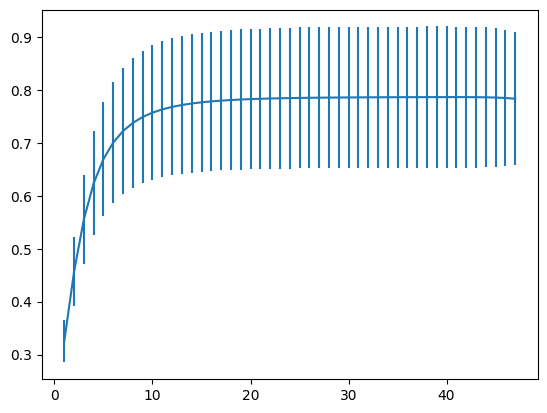

In [16]:
plt.errorbar( np.arange(1,int(Nt/2)), wall/a2a, np.abs(wall_err/a2a) )

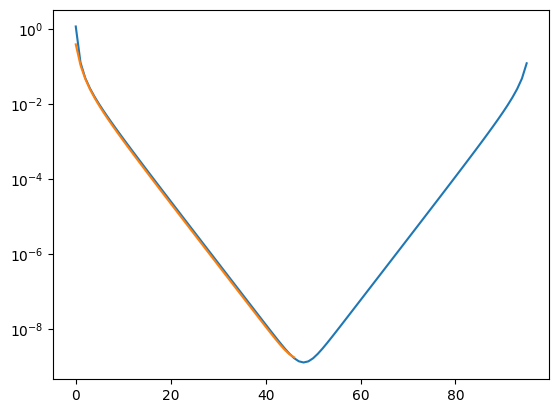

In [17]:
plt.plot( jk_00_00.mean() )
plt.plot( a2a )

plt.yscale("log")

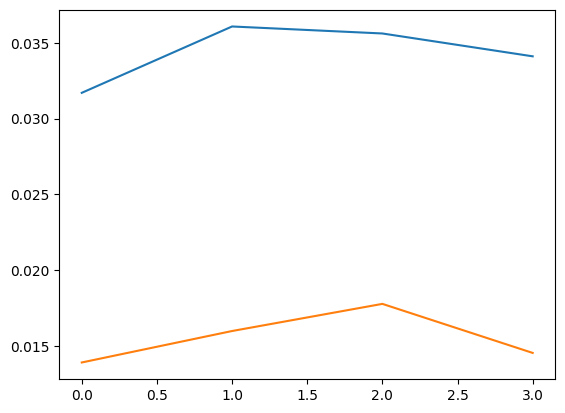

In [16]:
# jks33_=[]

ell=1

ninit=0
nt0s=4

corrs_aa = np.full( (nhits, Nt, 3), 0. )
corrs_33 = np.full( (nhits, Nt, 3), 0. )

# for em in [-1, 0, 1]:
em = 0
for ab in range(1,4):
    files_ = sorted(glob.glob(path+"/meson_"+str(ell)+"_"+str(em)+"_a"+str(ab)+"_h*_corr.*"), key=sorted) # @@@ ill ordered
    files = np.array(files_)[:nhits]

    corrs_=[]
    for file in natsorted(files)[ninit*nt0s:]:
#     for file in natsorted(files)[170:]:
        corr = np.loadtxt( file )
        corrs_.append( corr )

    corrs = np.array(corrs_)
    corrs_aa += corrs
    if ab==3:
        corrs_33 += corrs

plt.plot( np.mean(corrs_aa, axis=1).T[1] )
plt.plot( np.mean(corrs_33, axis=1).T[1] )

jk_1_aa = Jackknife( corrs_aa.shape[0], binsize )
jk_1_33 = Jackknife( corrs_33.shape[0], binsize )

jk_1_aa.set( take_real, corrs_aa/(2.0*ell+1.0) )
jk_1_33.set( take_real, corrs_33 )
# jk.set( take_imag, corrs )
jk_1_aa.do_it()
jk_1_33.do_it()

# jks_.append([ab, jk.mean(),jk.err()])
    
# plt.ylim(0.0045, 0.0046)

In [36]:
wall = jk_1_33.mean()[1:int(Nt/2)]
wall_err = jk_1_33.err()[1:int(Nt/2)]

a2a = np.loadtxt( "a2a_103_103.dat" ).T[1]

<ErrorbarContainer object of 3 artists>

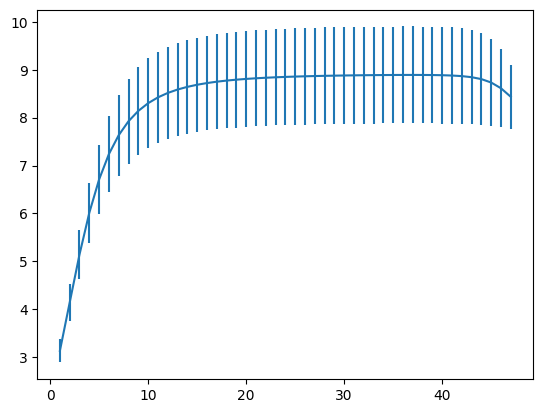

In [37]:
plt.errorbar( np.arange(1,int(Nt/2)), wall/a2a, wall_err/a2a )

In [31]:
len(wall[1:int(Nt/2)])

47

In [27]:
len(a2a.T[1])

47

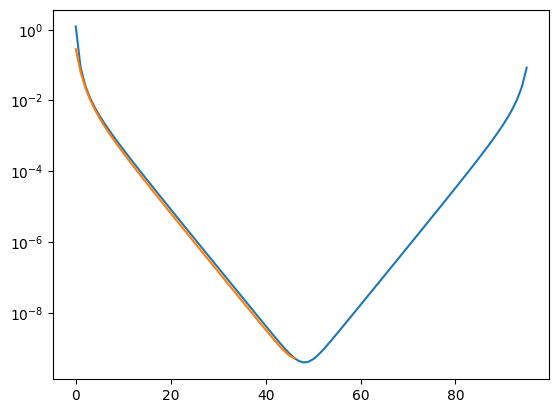

In [25]:
plt.plot( jk_1_33.mean() )
plt.plot( a2a.T[1] )

plt.yscale("log")

In [34]:
# jks33_=[]

ell=2

ninit=0
nt0s=4

nhits = 1

corrs_aa = np.full( (nhits, Nt, 3), 0. )
corrs_11 = np.full( (nhits, Nt, 3), 0. )
corrs_22 = np.full( (nhits, Nt, 3), 0. )
corrs_33 = np.full( (nhits, Nt, 3), 0. )

for em in np.arange(-ell, ell+1):
    for ab in range(1,4):
        files_ = sorted(glob.glob(path+"/meson_"+str(ell)+"_"+str(em)+"_a"+str(ab)+"_h*_corr.*"), key=sorted) # @@@ ill ordered
        files = np.array(files_)[:nhits]
    
        corrs_=[]
        for file in natsorted(files)[ninit*nt0s:]:
    #     for file in natsorted(files)[170:]:
            corr = np.loadtxt( file )
            corrs_.append( corr )
    
        corrs = np.array(corrs_)
        corrs_aa += corrs
        if ab==1:
            corrs_11 += corrs
        elif ab==2:
            corrs_22 += corrs
        elif ab==3:
            corrs_33 += corrs
    
    plt.plot( np.mean(corrs_aa, axis=1).T[1] )
    plt.plot( np.mean(corrs_33, axis=1).T[1] )

jk_2_aa = Jackknife( corrs_aa.shape[0], binsize )
jk_2_11 = Jackknife( corrs_11.shape[0], binsize )
jk_2_22 = Jackknife( corrs_22.shape[0], binsize )
jk_2_33 = Jackknife( corrs_33.shape[0], binsize )

jk_2_aa.set( take_real, corrs_aa/(2.0*ell+1.0) )
jk_2_11.set( take_real, corrs_11 )
jk_2_22.set( take_real, corrs_22 )
jk_2_33.set( take_real, corrs_33 )
# jk.set( take_imag, corrs )

jk_2_aa.do_it()
jk_2_11.do_it()
jk_2_22.do_it()
jk_2_33.do_it()
    
# jks_.append([ab, jk.mean(),jk.err()])
    
# plt.ylim(0.0045, 0.0046)

ValueError: operands could not be broadcast together with shapes (1,96,3) (0,) (1,96,3) 

In [29]:
jk_2_11I = Jackknife( corrs_11.shape[0], binsize )
jk_2_11I.set( take_imag, corrs_11 )

jk_2_11I.do_it()

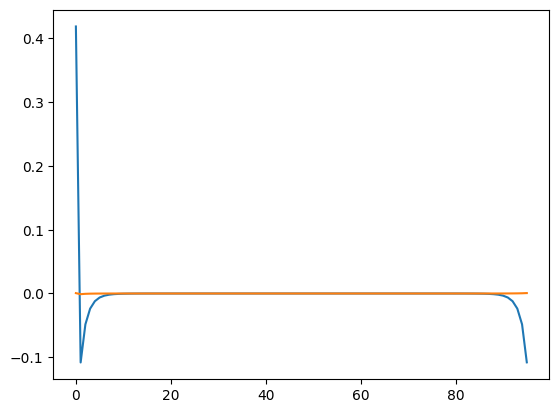

In [31]:
plt.plot( jk_2_11.mean() )
plt.plot( jk_2_11I.mean() )


In [20]:
desc="at"+str(at)+"_nu0"+str(nu0)+"_nu1"+str(nu1)

In [21]:
xxx = float(at) * np.arange(Nt)

/tmp/ipykernel_51858/658105652.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0.0, 1.0)


(7.72653625895317e-14, 1.0)

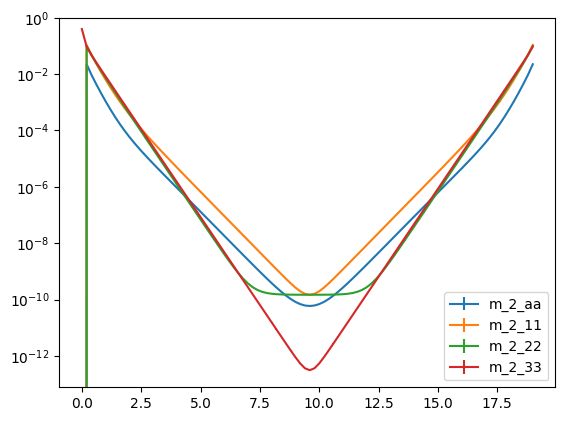

In [25]:
plt.errorbar( xxx, -jk_2_aa.mean(), jk_2_aa.err(), label="m_2_aa" )

plt.errorbar( xxx, -jk_2_11.mean(), jk_2_11.err(), label="m_2_11" )
plt.errorbar( xxx, -jk_2_22.mean(), jk_2_22.err(), label="m_2_22" )
plt.errorbar( xxx, jk_2_33.mean(), jk_2_33.err(), label="m_2_33" )
plt.yscale("log")

plt.legend()

plt.ylim(0.0, 1.0)

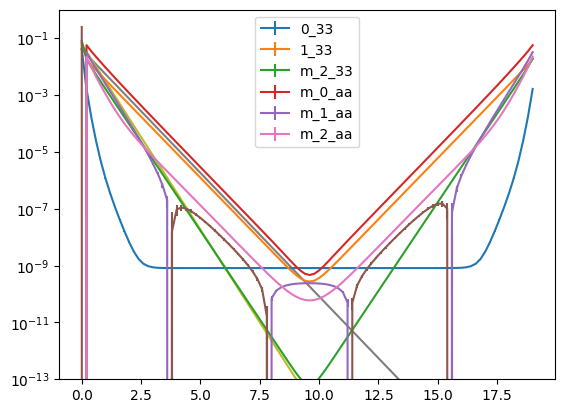

In [29]:
# shouldn't exist
plt.errorbar( xxx, jk_0_33.mean(), jk_0_33.err(), label="0_33" )
plt.errorbar( xxx, jk_1_33.mean(), jk_1_33.err(), label="1_33" )
plt.errorbar( xxx, jk_2_33.mean(), jk_2_33.err(), label="m_2_33" )

# 

plt.errorbar( xxx, -jk_0_aa.mean(), jk_0_aa.err(), label="m_0_aa" )

plt.errorbar( xxx, -jk_1_aa.mean(), jk_1_aa.err(), label="m_1_aa" )
plt.errorbar( xxx, jk_1_aa.mean(), jk_1_aa.err(), label="_1_aa" )

plt.errorbar( xxx, -jk_2_aa.mean(), jk_2_aa.err(), label="m_2_aa" )


plt.plot( xxx, 0.04*np.exp(-2*xxx) )
plt.plot( xxx, 0.06*np.exp(-3*xxx) )

plt.yscale("log")
plt.ylim(1.0e-13, 1.0e0)

plt.legend()

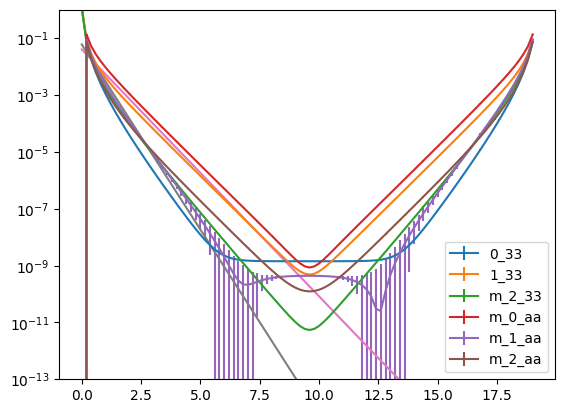

In [40]:
# shouldn't exist
plt.errorbar( xxx, jk_0_33.mean(), jk_0_33.err(), label="0_33" )
plt.errorbar( xxx, jk_1_33.mean(), jk_1_33.err(), label="1_33" )
plt.errorbar( xxx, jk_2_33.mean(), jk_2_33.err(), label="m_2_33" )

# 

plt.errorbar( xxx, -jk_0_aa.mean(), jk_0_aa.err(), label="m_0_aa" )
plt.errorbar( xxx, -jk_1_aa.mean(), jk_1_aa.err(), label="m_1_aa" )
plt.errorbar( xxx, -jk_2_aa.mean(), jk_2_aa.err(), label="m_2_aa" )


plt.plot( xxx, 0.04*np.exp(-2*xxx) )
plt.plot( xxx, 0.06*np.exp(-3*xxx) )

plt.yscale("log")
plt.ylim(1.0e-13, 1.0e0)

plt.legend()

In [19]:
def meff( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

class Coeff:
    def __init__(self, m0):
        self.m0 = m0

    def __call__( self, x, A  ):
        return -self.m0*x + A # + B * np.exp(-m2*x)

In [20]:
fitm = int(3.0/float(at))
fitM = int(7.0/float(at))

corr = jk_1_33.mean()

In [21]:
yyy = -np.log( corr[1:]/corr[:-1] )/float(at)

opt = sp.optimize.curve_fit( meff, xxx[fitm:fitM], yyy[fitm:fitM],
                           p0=( 2.0, 1.0, 1.0 ), 
                           full_output=True, absolute_sigma=True )

(0.0, 12.0)

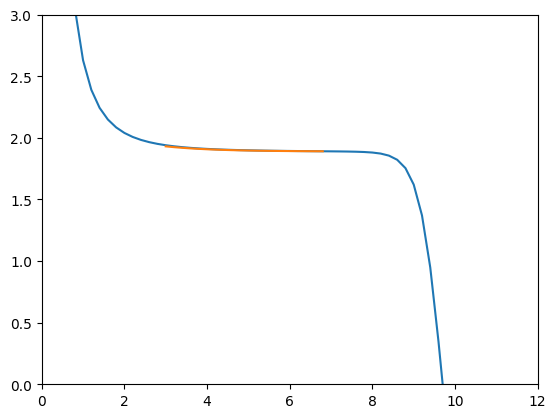

In [22]:
plt.plot( xxx[1:], yyy )
plt.plot( xxx[fitm:fitM], meff(xxx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.ylim(0, 3)
plt.xlim(0, 12.0)

In [23]:
coeff = Coeff( opt[0][0] )

opt2 = sp.optimize.curve_fit( coeff, xxx[fitm:fitM], np.log(corr[fitm:fitM]),
                        p0=( -4.0 ), 
                        full_output=True, absolute_sigma=True )

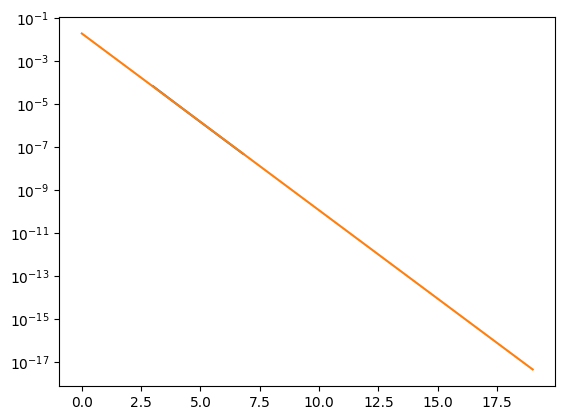

In [24]:
plt.plot( xxx[fitm:fitM], corr[fitm:fitM] )
plt.plot( xxx, np.exp( coeff( xxx, opt2[0][0] )) )

plt.yscale("log")

In [25]:
A1_33, M1_33 = np.exp(opt2[0][0]), opt[0][0]

In [26]:
fitm = int(5.0/float(at))
fitM = int(7.0/float(at))

corr = jk_2_33.mean()

In [27]:
yyy = -np.log( corr[1:]/corr[:-1] )/float(at)

opt = sp.optimize.curve_fit( meff, xxx[fitm:fitM], yyy[fitm:fitM],
                           p0=( 2.0, 1.0, 1.0 ), 
                           full_output=True, absolute_sigma=True )

(0.0, 8.0)

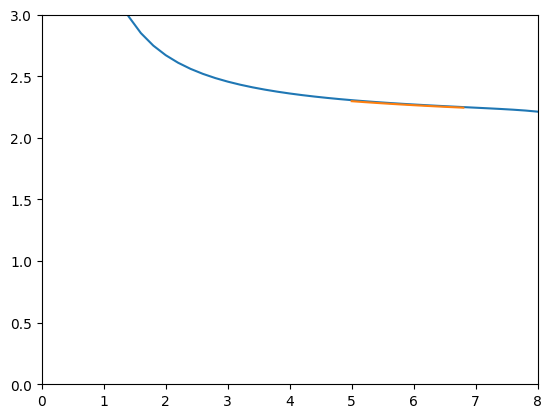

In [28]:
plt.plot( xxx[1:], yyy )
plt.plot( xxx[fitm:fitM], meff(xxx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.ylim(0, 3)
plt.xlim(0, 8.0)

In [29]:
coeff = Coeff( opt[0][0] )

opt2 = sp.optimize.curve_fit( coeff, xxx[fitm:fitM], np.log(corr[fitm:fitM]),
                        p0=( -4.0 ), 
                        full_output=True, absolute_sigma=True )

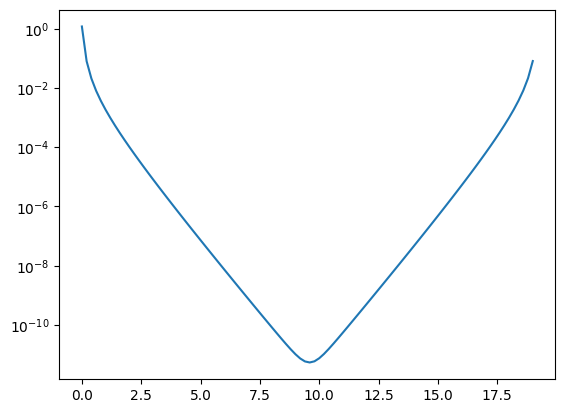

In [32]:
plt.plot( xxx, corr )
# plt.plot( xxx[fitm:fitM], corr[fitm:fitM] )
# plt.plot( xxx, np.exp( coeff( xxx, opt2[0][0] )) )

# plt.plot( xxx, A2_33*np.exp( -M2_33* xxx) )

plt.yscale("log")

In [33]:
A2_33, M2_33 = np.exp(opt2[0][0]), opt[0][0]

In [45]:
fitm = int(4.0/float(at))
fitM = int(6.0/float(at))

corr = jk_2_aa.mean()

In [46]:
yyy = -np.log( corr[1:]/corr[:-1] )/float(at)

opt = sp.optimize.curve_fit( meff, xxx[fitm:fitM], yyy[fitm:fitM],
                           p0=( 2.0, 1.0, 1.0 ), 
                           full_output=True, absolute_sigma=True )

/tmp/ipykernel_18759/2705096815.py:1: RuntimeWarning: invalid value encountered in log
  yyy = -np.log( corr[1:]/corr[:-1] )/float(at)


(0.0, 8.0)

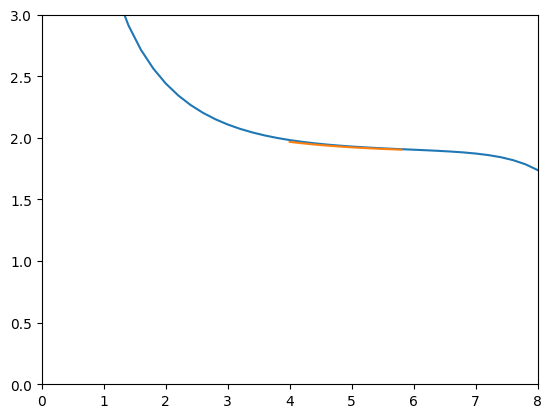

In [47]:
plt.plot( xxx[1:], yyy )
plt.plot( xxx[fitm:fitM], meff(xxx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.ylim(0, 3)
plt.xlim(0, 8.0)

In [50]:
coeff = Coeff( opt[0][0] )

opt2 = sp.optimize.curve_fit( coeff, xxx[fitm:fitM], np.log(-corr[fitm:fitM]),
                        p0=( -4.0 ), 
                        full_output=True, absolute_sigma=True )

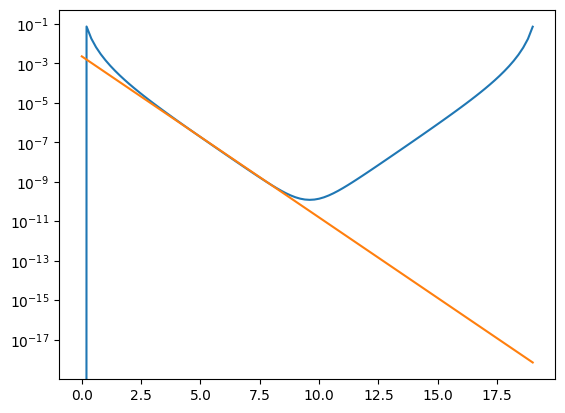

In [53]:
plt.plot( xxx, -corr )
# plt.plot( xxx[fitm:fitM], corr[fitm:fitM] )
plt.plot( xxx, np.exp( coeff( xxx, opt2[0][0] )) )

# plt.plot( xxx, A2_33*np.exp( -M2_33* xxx) )

plt.yscale("log")

In [54]:
A2_aa, M2_aa = np.exp(opt2[0][0]), opt[0][0]

In [34]:
A1_33, M1_33

(0.018162098633156043, 1.8895950650526852)

In [35]:
A2_33, M2_33

(0.0033457392512654307, 2.1667062233413974)

In [55]:
A2_aa, M2_aa

(0.002286552146127498, 1.8793619759485904)

In [58]:
diff = [2.0-M1_33, 3.0-M2_33, 4.0-M2_aa ]

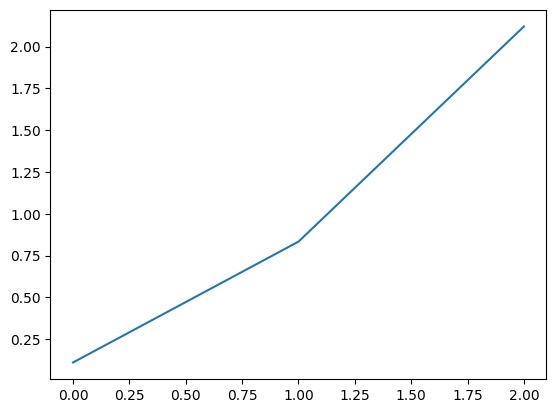

In [60]:
plt.plot( diff )

In [36]:
M1_33/M2_33

0.8721048773001797

In [37]:
A1_33/A2_33

5.428426206939691

In [38]:
1./3. / (4./5.)

0.41666666666666663

/tmp/ipykernel_8202/4016297898.py:3: RuntimeWarning: invalid value encountered in log
  plt.plot( xxx[1:], -np.log( corr[1:]/corr[:-1] )/float(at) )


(0.0, 8.0)

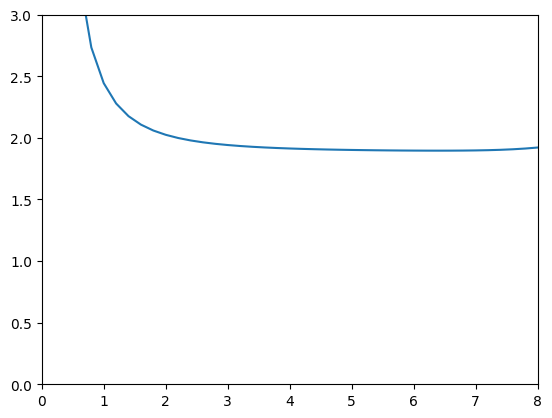

In [38]:
corr = jk_0_aa.mean()

plt.plot( xxx[1:], -np.log( corr[1:]/corr[:-1] )/float(at) )
plt.ylim(0, 3)
plt.xlim(0, 8.0)

(-2.0, 2.0)

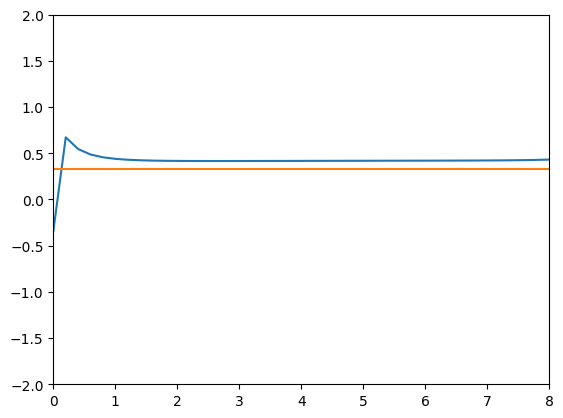

In [27]:
plt.plot( xxx, -jk_1_33.mean()/jk_0_aa.mean()  )

plt.plot( xxx, np.full( xxx.size, 1.0/3.0 ) )
# plt.plot( xxx, np.full( xxx.size, 2.0/5.0 ) )

plt.xlim(0, 8)
plt.ylim(-2, 2)

In [ ]:
plt.plot( xxx, -jk_1_33.mean()/jk_0_aa.mean()  )

plt.plot( xxx, np.full( xxx.size, 1.0/3.0 ) )
# plt.plot( xxx, np.full( xxx.size, 2.0/5.0 ) )

plt.xlim(0, 8)
plt.ylim(-2, 2)

In [28]:
# # shouldn't exist
# plt.errorbar( xxx, jk_00_33.mean(), jk_00_33.err(), label="00_33" )

# plt.errorbar( xxx, jk_10_33.mean(), jk_10_33.err(), label="10_33" )

# plt.errorbar( xxx, jk_20_33.mean(), jk_20_33.err(), label="m_20_33" )

# # 

# plt.errorbar( xxx, -jk_00_aa.mean(), jk_00_aa.err(), label="m_00_aa" )

# # plt.errorbar( xxx, -jk_10_aa.mean(), jk_10_aa.err(), label="m_10_aa" )
# # plt.errorbar( xxx, -jk_1M1_aa.mean(), jk_1M1_aa.err(), label="m_1m1_aa" )
# # plt.errorbar( xxx, -jk_11_aa.mean(), jk_11_aa.err(), label="m_11_aa" )

# # plt.errorbar( xxx, -jk_11_aa.mean(), jk_11_aa.err(), label="m_11_aa" )

# plt.errorbar( xxx, (-jk_1M1_aa.mean()-jk_10_aa.mean()-jk_11_aa.mean())/3.0, jk_10_aa.err(), label="m_10_aa" )

# # plt.plot( xxx, 0.04*np.exp(-2.0*xxx) )
# # plt.plot( xxx, 0.06*np.exp(-3.0*xxx) )

# plt.plot( xxx, 0.04*np.exp(-2*xxx) )
# plt.plot( xxx, 0.06*np.exp(-3*xxx) )

# plt.yscale("log")
# plt.ylim(1.0e-13, 1.0e0)

# plt.legend()

(-2.0, 2.0)

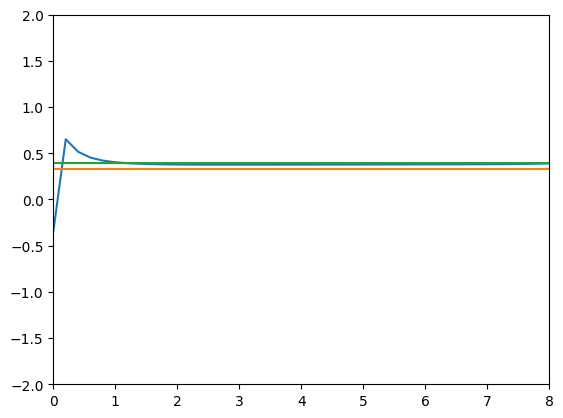

In [40]:
plt.plot( xxx, -jk_10_33.mean()/jk_00_aa.mean()  )

plt.plot( xxx, np.full( xxx.size, 1.0/3.0 ) )
plt.plot( xxx, np.full( xxx.size, 2.0/5.0 ) )

plt.xlim(0, 8)
plt.ylim(-2, 2)

In [16]:
jks_[0][1][47]

-6.88946592273352e-10

In [17]:
# 1.3157697610054052e-09

In [22]:
-jks_[0][1][47]

6.88946592273352e-10

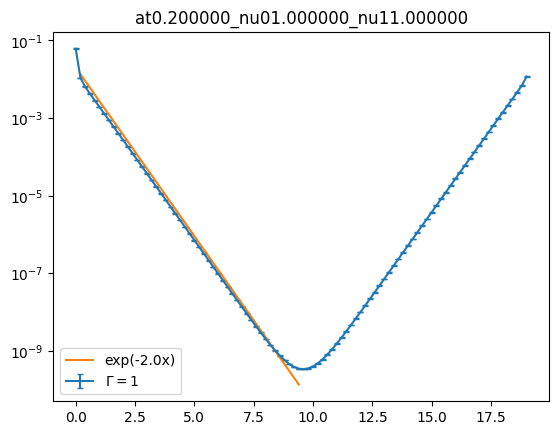

In [22]:
# plt.errorbar(np.arange(1,Nt/2)*float(at), jks_[0][1], jks_[0][2], capsize=2.0, label='$\\Gamma=1$')

plt.errorbar(np.arange(Nt)*float(at), np.abs(jks_[0][1])+jks_[0][1][47], jks_[0][2], capsize=2.0, label='$\\Gamma=1$')
# plt.errorbar(np.arange(Nt)*float(at), jks_[1][1], jks_[1][2], capsize=2.0, label='$\\Gamma=\\sigma_1$')
# plt.errorbar(np.arange(Nt)*float(at), jks_[2][1], jks_[2][2], capsize=2.0, label='$\\Gamma=\\sigma_2$')
# plt.errorbar(np.arange(Nt)*float(at), jks_[3][1], jks_[3][2], capsize=2.0, label='$\\Gamma=\\sigma_3$')
plt.yscale("log")
plt.title(desc)

# plt.plot( np.arange(Nt)*float(at), free.T[1], label='free', ls='dashed' )

x = np.arange(1,Nt/2)*float(at)
# plt.plot(x, 0.008*np.exp(-2.4*x), label="exp(-2.6x)")
plt.plot(x, 0.02*np.exp(-2.0*x), label="exp(-2.0x)")

# plt.ylim(1.0e-4, 1.0e-5)
plt.legend()

plt.savefig( desc+"_wall.pdf", bbox_inches="tight" )

In [19]:
# fitm = int(5.0 / 0.2)
# fitM = int(8.0 / 0.2)

fitm = int(1.2 / 0.2)
fitM = int(5.0 / 0.2)


def meff( cor ):
    avg = (cor[1:int(Nt/2)] + np.flip(cor[int(Nt/2)+1:]))/2
    tmp = np.arccosh(avg/cor[int(Nt/2)])
    return (-tmp[1:]+tmp[:-1])/float(at)
    # return -np.log(avg[1:]/avg[:-1])/float(at)

xx = np.arange(1,int(Nt/2)-1)*float(at)

# def fitter( x, m1, m2, A ):
#     return np.full( x.shape[0], m1)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

# def meff( cor ):
#     tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
#     return (-tmp[1:]+tmp[:-1])/float(at)

In [40]:
jk_M = []

for l1_1 in jk.jack_avg:
    jk_M.append( meff(l1_1) )

In [41]:
jk_meff = Jackknife( len(jk_M), 1 )
jk_meff.set( jack_avg, jk_M )
jk_meff.do_it()

In [42]:
jk_mass=[]

for l1_1 in jk.jack_avg:
    yy = meff(l1_1)

    opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                                 sigma=jk_meff.err()[fitm:fitM],
                           p0=(np.sqrt(2.0), 2, 0.01 ), 
                           full_output=True, absolute_sigma=True )

    jk_mass.append( opt[0] )

/tmp/ipykernel_5721/3226063778.py:20: RuntimeWarning: overflow encountered in exp
  return m1 + A * np.exp(-m2*x)


In [43]:
jk_fit = Jackknife( len(jk_mass), binsize )
jk_fit.set( jack_avg, jk_mass )
jk_fit.do_it()

In [44]:
jk_fit.mean()

array([1.44291323, 0.85361311, 3.73484802])

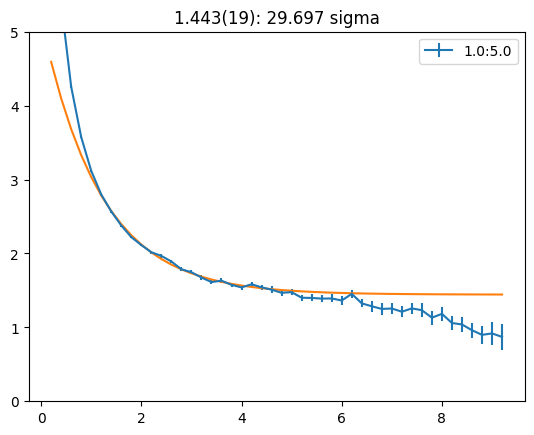

In [45]:
plt.errorbar( xx, jk_meff.mean(), jk_meff.err(), label=str(fitm*float(at))+":"+str(fitM*float(at)) )

plt.plot( xx, fitter(xx, jk_fit.mean()[0], jk_fit.mean()[1], jk_fit.mean()[2] ) )

plt.ylim(0.0,5.0)

plt.title(format_print_w_exact(2.0+ell, jk_fit.mean()[0], jk_fit.err()[0] ))
plt.legend()

plt.savefig( desc+"_fit"+str(ell)+str(em)+".pdf", bbox_inches="tight" )

In [23]:
opt

(array([1.81653499, 1.12126363, 3.94230431]),
 array([[0.00497287, 0.01252909, 0.04488511],
        [0.01252909, 0.04497264, 0.19114834],
        [0.04488511, 0.19114834, 0.87826923]]),
 {'fvec': array([-0.75976354,  0.6890516 ,  0.44451578, -0.01989423, -0.6149857 ,
         -0.01525778,  0.20090733, -0.75311796, -0.46867176,  1.02355405,
         -0.95610251,  0.91122916, -0.17313256, -1.17578566,  0.255932  ,
          0.70738534,  0.41310475,  0.52647795, -0.43987899, -0.01795451]),
  'nfev': 82,
  'fjac': array([[-4.88712673e+01,  4.11033420e-01,  4.07269378e-01,
           3.29931993e-01,  2.83724210e-01,  2.24662903e-01,
           2.18697340e-01,  1.75279930e-01,  2.19231666e-01,
           1.44573860e-01,  1.93144323e-01,  1.42856992e-01,
           1.50446056e-01,  1.06569119e-01,  1.26167998e-01,
           1.72187242e-01,  1.12711763e-01,  9.98113299e-02,
           9.02063280e-02,  8.60139181e-02],
         [ 4.00195622e+01,  1.72241931e+01,  1.50142399e-01,
           2.2

In [24]:
results.append( [nu0, yy] )

In [54]:
desc="Nf"+str(Nf)+"_gsq"+str(gsq)+"_at"+str(at)

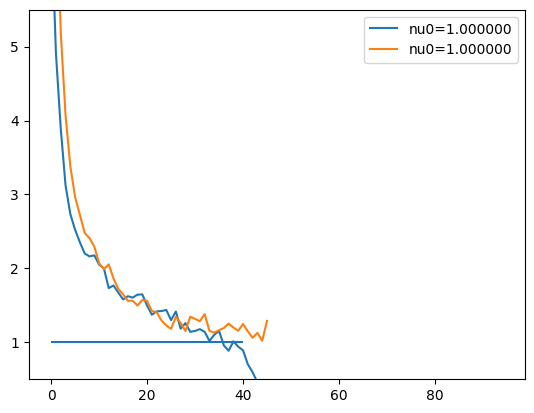

In [57]:
for result in results:
    plt.plot( result[1], label='nu0='+result[0] )

plt.hlines(1.0, 0,40)
plt.legend()

plt.ylim(0.5, 5.5)
plt.savefig( desc+"_meff_wall.pdf", bbox_inches="tight" )

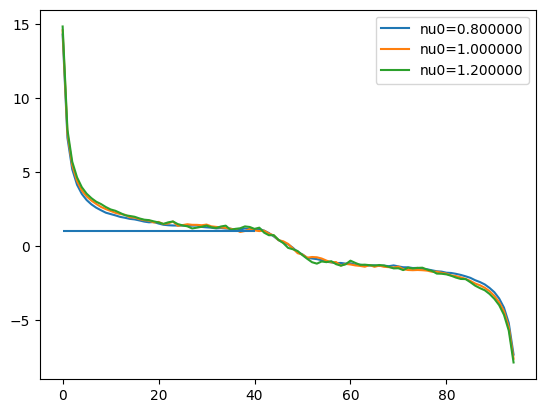

In [54]:
for result in results:
    plt.plot( result[1], label='nu0='+result[0] )

plt.hlines(1.0, 0,40)
plt.legend()

plt.savefig( desc+"_meff_wall.pdf", bbox_inches="tight" )

In [55]:
results

[['0.800000',
  array([14.31135073,  7.32799627,  5.19935481,  4.15273213,  3.53193435,
          3.11899384,  2.82506991,  2.60155771,  2.42719058,  2.26364864,
          2.17139397,  2.08068865,  1.97974129,  1.91857776,  1.84572363,
          1.80940649,  1.73934755,  1.66170358,  1.61394484,  1.63033047,
          1.5303927 ,  1.44781997,  1.41516604,  1.39760592,  1.39188435,
          1.39350314,  1.36891993,  1.38751764,  1.39664116,  1.29992616,
          1.27215703,  1.24686085,  1.20057877,  1.22311721,  1.19078713,
          1.18530826,  1.07578871,  1.1294769 ,  1.19696926,  1.1534396 ,
          1.15087212,  1.15994308,  1.05108651,  0.88791309,  0.66120695,
          0.40940391,  0.24658396,  0.1207837 , -0.110848  , -0.40858376,
         -0.55914197, -0.79508303, -0.83566636, -0.87745112, -0.94929671,
         -1.05437737, -1.09733747, -1.14852648, -1.13609956, -1.1806056 ,
         -1.15748134, -1.25680998, -1.25381433, -1.3113634 , -1.30914686,
         -1.29778202, -1

In [3]:
# 1 0.138394
# 2 0.073868
# 4 2.994744726728921e-01

In [4]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [5]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [6]:
Nt=96

In [7]:
gsq=0.50000
beta=1.0/gsq

In [8]:
# gsq=2.00000
# beta=1.0/gsq

# key_1='gsq2.000000at0.500000nt24L1__corr'
# key_2='gsq2.000000at0.500000nt24L2__corr'
# # key_4='gsq0.500000at0.375000nt32L4_'

# l1_1 = np.loadtxt("corr_"+key_1+".dat")
# l1_2 = np.loadtxt("corr_"+key_2+".dat")
# # l1_4 = np.loadtxt("corr_"+key_4+".dat")

In [9]:
# plt.yscale("log")

# xx=np.arange(24)*0.5000
# plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
# plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
# # plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

# xx=np.linspace(0, 12, 5000)

# yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

# yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='red', label='exact' )

# plt.xlabel("$t$")
# plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

# plt.xlim(0, 12)
# plt.ylim(1.0e-5, 1.0e2)
# plt.legend()

# # plt.savefig("jtjt.pdf")

In [12]:
key_1='gsq0.500000at0.500000nt24L1__corr'
key_2='gsq0.500000at0.500000nt24L2__corr'
key_4='gsq0.500000at0.500000nt24L4__corr'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
l1_4 = np.loadtxt("corr_"+key_4+".dat")

FileNotFoundError: corr_gsq0.500000at0.500000nt24L4__corr.dat not found.

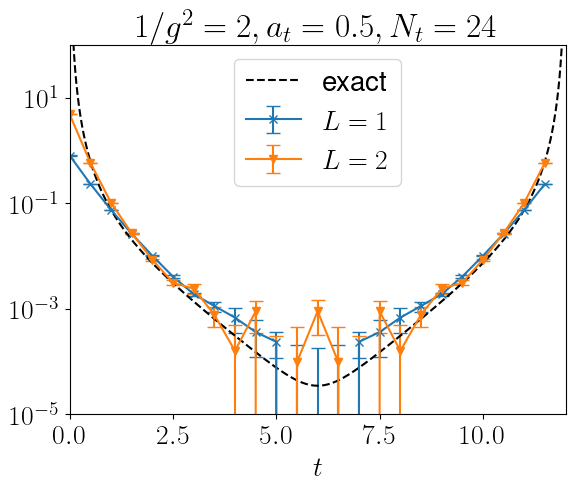

In [11]:
plt.yscale("log")

xx=np.arange(24)*0.5000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
# plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

# yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='red', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 2, a_t=0.5, N_t=24$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

plt.savefig("jtjt_Nt24.pdf")

In [42]:
key_1='gsq0.500000at0.500000nt24L1__meff'
key_2='gsq0.500000at0.500000nt24L2__meff'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

(-2.0, 7.0)

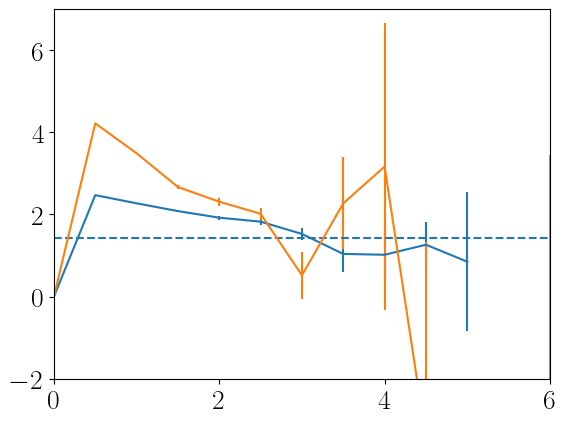

In [30]:
xx=np.arange(24)*0.5000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1] )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1] )
plt.hlines( np.sqrt(2.0), 0, 6, ls='dashed' )
plt.xlim(0,6)
plt.ylim(-2,7)

In [43]:
key_1='gsq0.500000at0.375000nt32L1__corr'
key_2='gsq0.500000at0.375000nt32L2__corr'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

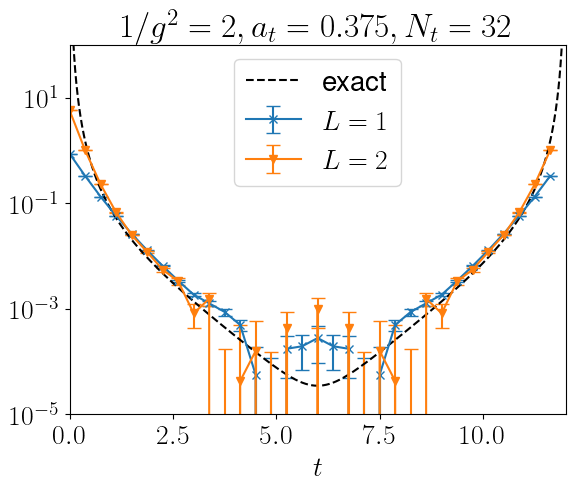

In [44]:
plt.yscale("log")

xx=np.arange(32)*0.375000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
# plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

# yy= (1.0/beta)*f(xx, 2, 12) # *fixme*
# plt.plot( xx, yy, ls='dashed', c='red', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 2, a_t=0.375, N_t=32$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

plt.savefig("jtjt_Nt32.pdf")

In [33]:
key_1='gsq0.500000at0.375000nt32L1__meff'
key_2='gsq0.500000at0.375000nt32L2__meff'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

(-2.0, 7.0)

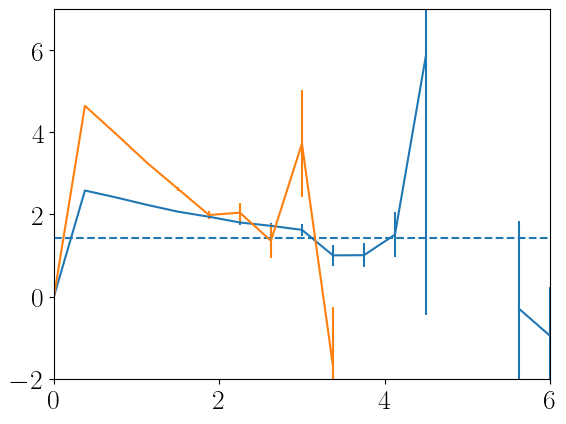

In [34]:
xx=np.arange(32)*0.375000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1] )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1] )
plt.hlines( np.sqrt(2.0), 0, 6, ls='dashed' )
plt.xlim(0,6)
plt.ylim(-2,7)

In [25]:
key_1='gsq0.500000at0.250000nt48L1__corr'
key_2='gsq0.500000at0.250000nt48L2__corr'
key_4='gsq0.500000at0.250000nt48L4__corr'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
l1_4 = np.loadtxt("corr_"+key_4+".dat")

In [13]:
binsize=100

In [ ]:
plt.yscale("log")

xx=np.arange(48)*0.25
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [26]:
l1_4

array([[ 2.58567e+01,  1.34919e+00],
       [ 3.08479e+00,  1.60966e-01],
       [ 5.51226e-01,  2.87768e-02],
       [ 1.51047e-01,  7.93309e-03],
       [ 5.93289e-02,  3.22455e-03],
       [ 3.15004e-02,  2.00753e-03],
       [ 1.63628e-02,  1.24101e-03],
       [ 7.25426e-03,  1.02069e-03],
       [ 3.06745e-03,  1.06143e-03],
       [ 1.46954e-05,  8.76100e-04],
       [-8.55911e-04,  1.00474e-03],
       [ 1.69758e-04,  9.64366e-04],
       [-3.48861e-04,  9.06459e-04],
       [ 2.80285e-03,  9.75635e-04],
       [ 3.59740e-03,  1.10333e-03],
       [ 2.56943e-03,  9.23602e-04],
       [ 2.84282e-03,  1.01567e-03],
       [-1.56302e-04,  8.19089e-04],
       [-9.99339e-04,  1.03418e-03],
       [-4.02704e-03,  9.82837e-04],
       [-3.54848e-03,  1.02323e-03],
       [-2.90794e-04,  9.19606e-04],
       [ 1.35805e-03,  8.99457e-04],
       [ 8.94548e-04,  7.69531e-04],
       [ 2.73321e-03,  1.39947e-03],
       [ 8.94548e-04,  7.69531e-04],
       [ 1.35805e-03,  8.99457e-04],
 

In [20]:
l1_4

array([[ 3.91890e+01,  1.04023e-01],
       [ 4.67528e+00,  1.23822e-02],
       [ 8.35318e-01,  2.77511e-03],
       [ 2.29001e-01,  1.68260e-03],
       [ 8.98009e-02,  1.45274e-03],
       [ 4.78226e-02,  1.99381e-03],
       [ 2.50659e-02,  1.44156e-03],
       [ 1.11009e-02,  1.59928e-03],
       [ 4.57388e-03,  1.69327e-03],
       [-2.16450e-04,  1.35749e-03],
       [-1.29176e-03,  1.74603e-03],
       [ 4.26626e-04,  1.58079e-03],
       [-5.45515e-04,  1.48398e-03],
       [ 4.18315e-03,  1.56814e-03],
       [ 5.55080e-03,  1.69779e-03],
       [ 3.83686e-03,  1.51308e-03],
       [ 4.38214e-03,  1.70357e-03],
       [-4.12958e-04,  1.30468e-03],
       [-1.83008e-03,  1.75276e-03],
       [-5.94236e-03,  1.55223e-03],
       [-5.51766e-03,  1.61519e-03],
       [-2.71268e-04,  1.49109e-03],
       [ 2.21970e-03,  1.45413e-03],
       [ 1.09788e-03,  1.14711e-03],
       [ 4.38789e-03,  2.14837e-03],
       [ 1.09788e-03,  1.14711e-03],
       [ 2.21970e-03,  1.45413e-03],
 

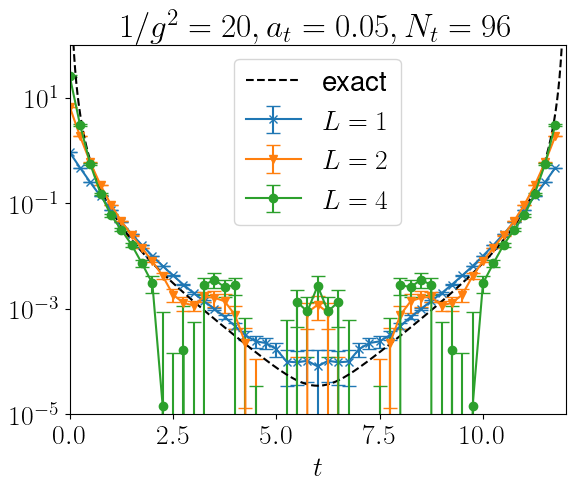

In [27]:
plt.yscale("log")

xx=np.arange(48)*0.25
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [15]:
binsize=2000

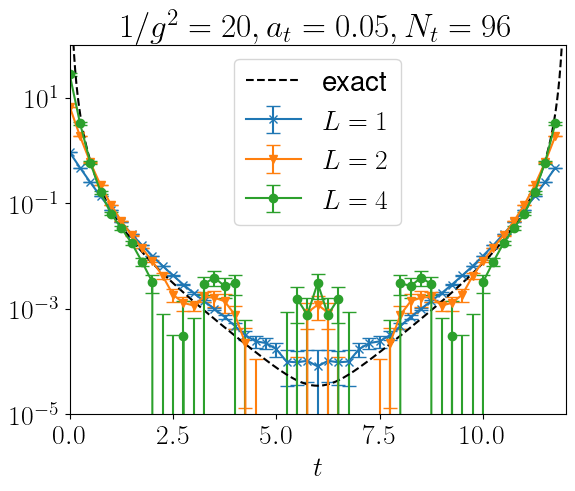

In [16]:
plt.yscale("log")

xx=np.arange(48)*0.25
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 12, 5000)

yy= (1.0/beta)*f(xx, 4000, 12) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 12)
plt.ylim(1.0e-5, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [39]:
key_1='gsq0.500000at0.250000nt48L1__meff'
key_2='gsq0.500000at0.250000nt48L2__meff'
# key_4='gsq0.500000at0.375000nt32L4_'

l1_1 = np.loadtxt("corr_"+key_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2+".dat")
# l1_4 = np.loadtxt("corr_"+key_4+".dat")

(-2.0, 7.0)

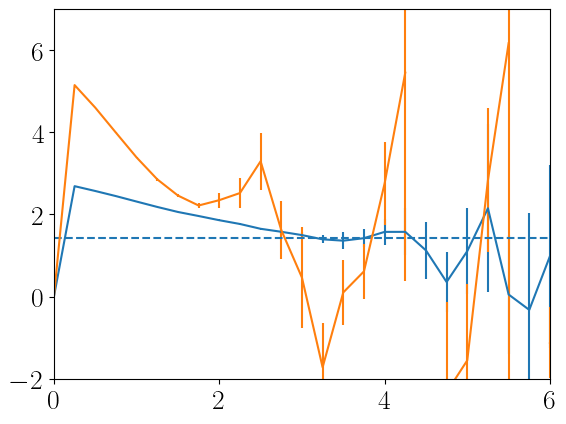

In [40]:
xx=np.arange(48)*0.25000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1] )
plt.errorbar( xx, l1_2.T[0], l1_2.T[1] )
plt.hlines( np.sqrt(2.0), 0, 6, ls='dashed' )
plt.xlim(0,6)
plt.ylim(-2,7)

In [16]:
at=0.25

/scratch/354095.1.ood/ipykernel_2309507/2497384176.py:1: RuntimeWarning: divide by zero encountered in divide
  meff = -np.log( l1_1.T[0][1:]/l1_1.T[0][:-1] )
/scratch/354095.1.ood/ipykernel_2309507/2497384176.py:1: RuntimeWarning: invalid value encountered in log
  meff = -np.log( l1_1.T[0][1:]/l1_1.T[0][:-1] )


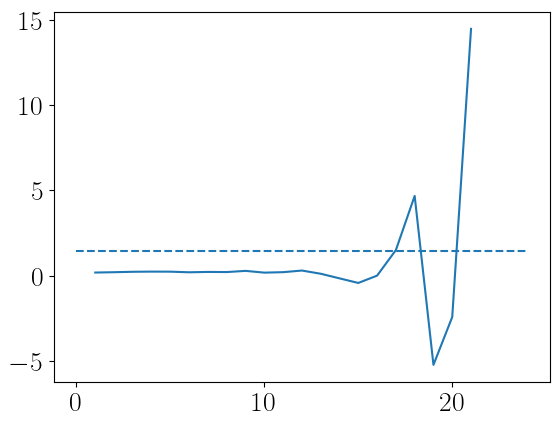

In [17]:
meff = -np.log( l1_1.T[0][1:]/l1_1.T[0][:-1] )

plt.plot( meff[:24]/at )
plt.hlines( np.sqrt(2.0), 0, 24, ls='dashed' )

/scratch/354095.1.ood/ipykernel_2309507/2068367678.py:1: RuntimeWarning: divide by zero encountered in divide
  meff = -np.log( l1_2.T[0][1:]/l1_2.T[0][:-1] )
/scratch/354095.1.ood/ipykernel_2309507/2068367678.py:1: RuntimeWarning: invalid value encountered in log
  meff = -np.log( l1_2.T[0][1:]/l1_2.T[0][:-1] )


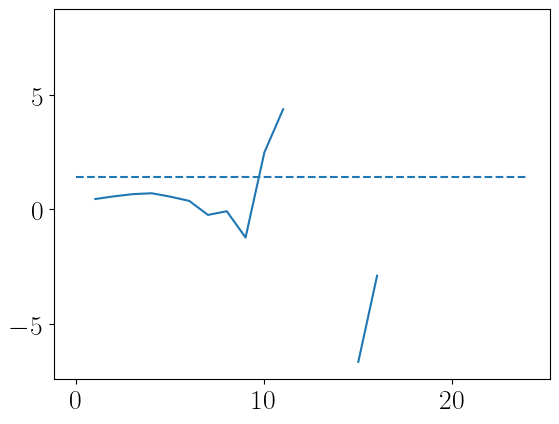

In [18]:
meff = -np.log( l1_2.T[0][1:]/l1_2.T[0][:-1] )

plt.plot( meff[:24]/at )
plt.hlines( np.sqrt(2.0), 0, 24, ls='dashed' )

In [10]:
96

96

In [13]:
at=0.050000
beta=20

key_2_1='gsq0.050000at0.100000nt48L2_'
key_2_2='gsq0.050000at0.075000nt64L2_'
key_2_3='gsq0.050000at0.050000nt96L2_'

In [14]:
l1_1 = np.loadtxt("corr_"+key_2_1+".dat")
l1_2 = np.loadtxt("corr_"+key_2_2+".dat")
# l1_3 = np.loadtxt("corr_"+key_3+".dat")
l1_4 = np.loadtxt("corr_"+key_2_3+".dat")
# l2 = np.loadtxt("corr_"+key+"nt96L2_short.dat")
# l4 = np.loadtxt("corr_"+key+"nt96L4_short.dat")

/scratch/352694.1.ood/ipykernel_470825/2989030815.py:1: UserWarning: loadtxt: input contained no data: "corr_gsq0.050000at0.100000nt48L2_.dat"
  l1_1 = np.loadtxt("corr_"+key_2_1+".dat")


IndexError: index 0 is out of bounds for axis 0 with size 0

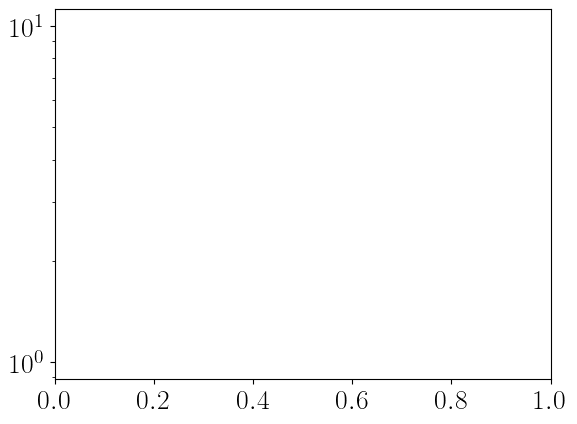

In [15]:
plt.yscale("log")

xx=np.arange(48)*0.100000
plt.errorbar( xx, l1_1.T[0], l1_1.T[1], capsize=5, fmt='x-', label="$L=1$" )
xx=np.arange(64)*0.075000
plt.errorbar( xx, l1_2.T[0], l1_2.T[1], capsize=5, fmt='v-', label="$L=2$" )
xx=np.arange(96)*0.050000
plt.errorbar( xx, l1_4.T[0], l1_4.T[1], capsize=5, fmt='o-', label="$L=4$" )

xx=np.linspace(0, 4.8, 5000)

yy= (1.0/beta)*f(xx, 4000, 4.8) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, a_t=0.05, N_t=96$")

plt.xlim(0, 5)
plt.ylim(1.0e-4, 1.0e2)
plt.legend()

# plt.savefig("jtjt.pdf")

In [ ]:
l1 = np.loadtxt("corr_beta5.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta5.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta5.000000at0.100000nt96L4.dat")

(0.0, 4.0)

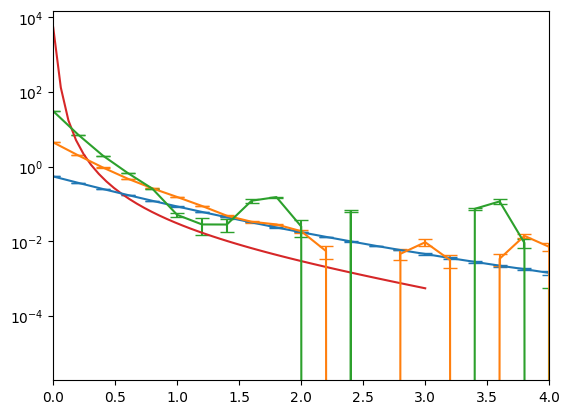

In [7]:
plt.yscale("log")

xx=np.arange(96)*0.2
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=1" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

# yy= (1.0/300.0)*f(xx, 6)
# plt.plot( xx, yy )

# yy= (1.0/800.0)*f(xx, 11)
# plt.plot( xx, yy )

# yy= (1.0/800.0)*f(xx, 20)
# plt.plot( xx, yy )

yy= (1.0/5.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

In [8]:
l1 = np.loadtxt("corr_beta20.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta20.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta20.000000at0.100000nt96L4.dat")

(0.0, 4.0)

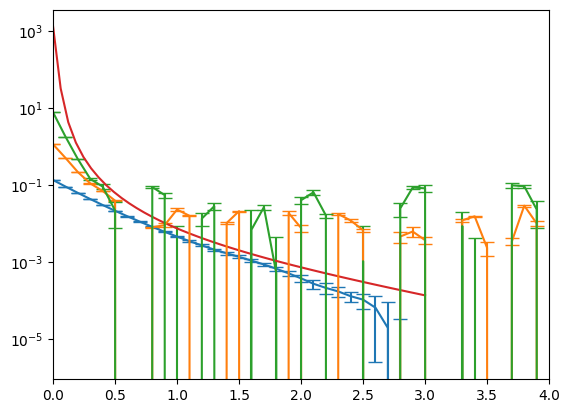

In [10]:
plt.yscale("log")

xx=np.arange(96)*0.1
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=1" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

# yy= (1.0/20.0)*f(xx, 6)
# plt.plot( xx, yy )

# yy= (1.0/20.0)*f(xx, 11)
# plt.plot( xx, yy )

# yy= (1.0/20.0)*f(xx, 20)
# plt.plot( xx, yy )

yy= (1.0/20.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

In [11]:
l1 = np.loadtxt("corr_beta50.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta50.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta50.000000at0.100000nt96L4.dat")

(0.0, 4.0)

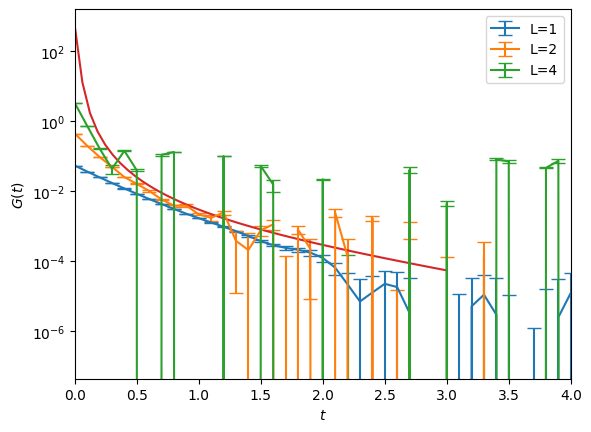

In [15]:
plt.yscale("log")

xx=np.arange(96)*0.1
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=2" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=4" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

# yy= (1.0/50.0)*f(xx, 6)
# plt.plot( xx, yy )

# yy= (1.0/50.0)*f(xx, 11)
# plt.plot( xx, yy )

# yy= (1.0/50.0)*f(xx, 20)
# plt.plot( xx, yy )

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$G(t)$")

yy= (1.0/50.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

In [17]:
l1 = np.loadtxt("corr_beta50.000000at0.100000nt96L1.dat")
l2 = np.loadtxt("corr_beta50.000000at0.100000nt96L2.dat")
l4 = np.loadtxt("corr_beta50.000000at0.100000nt96L4.dat")

(0.0, 4.0)

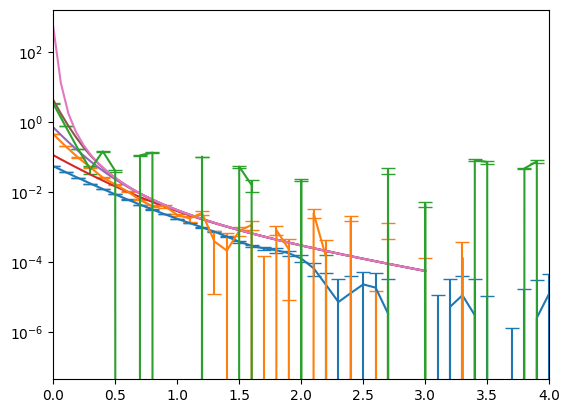

In [19]:
plt.yscale("log")

xx=np.arange(96)*0.1
plt.errorbar( xx, l1.T[0], l1.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l2.T[0], l2.T[1], capsize=5, label="L=1" )
plt.errorbar( xx, l4.T[0], l4.T[1], capsize=5, label="L=1" )


xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )

yy= (1.0/50.0)*f(xx, 6)
plt.plot( xx, yy )

yy= (1.0/50.0)*f(xx, 11)
plt.plot( xx, yy )

yy= (1.0/50.0)*f(xx, 20)
plt.plot( xx, yy )

yy= (1.0/50.0)*f(xx, 100)
plt.plot( xx, yy )


plt.xlim(0, 4)

(1e-05, 1.0)

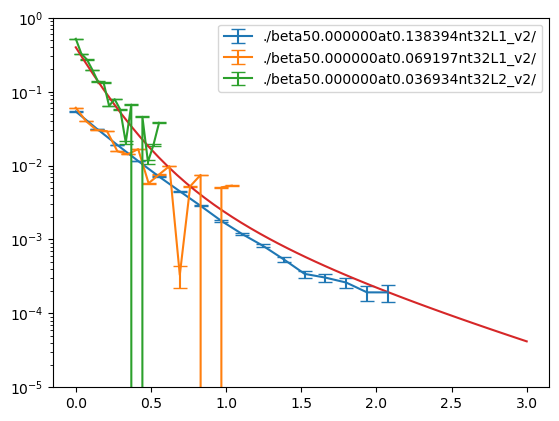

In [26]:
plt.yscale("log")

for res in res_list:
    Nt = res[1].shape[0]

    at = float(res[0].split("at")[1].split("nt")[0])
    xx=np.arange(int(Nt/2)) * at
    # xx=np.arange(Nt)
    yy=res[1][:int(Nt/2)]
    dy=res[2][:int(Nt/2)]

    plt.errorbar( xx, yy, dy, capsize=5, label=res[0] )

# xx=np.arange(Nt)
# yy= 0.07*np.exp( -np.sqrt(2.0) * xx / 8.0 )
# plt.plot( xx, yy )

xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )
yy= 0.0006*f(xx, 10)
plt.plot( xx, yy )



plt.legend()
plt.ylim( 1.0e-5, 1.0e0 )

In [7]:
l1

array([[ 1.36846e-01,  3.83936e-04],
       [ 9.27521e-02,  3.81009e-04],
       [ 6.35540e-02,  3.64255e-04],
       [ 4.40706e-02,  3.48425e-04],
       [ 3.09533e-02,  3.38998e-04],
       [ 2.19969e-02,  3.24321e-04],
       [ 1.58502e-02,  3.09281e-04],
       [ 1.15498e-02,  2.98567e-04],
       [ 8.51418e-03,  2.89944e-04],
       [ 6.34319e-03,  2.94173e-04],
       [ 4.79504e-03,  2.88819e-04],
       [ 3.69040e-03,  2.76160e-04],
       [ 2.90254e-03,  2.59906e-04],
       [ 2.33086e-03,  2.29066e-04],
       [ 1.94455e-03,  2.04223e-04],
       [ 1.64468e-03,  1.87646e-04],
       [ 1.36795e-03,  1.69771e-04],
       [ 1.12203e-03,  1.53549e-04],
       [ 8.84507e-04,  1.36835e-04],
       [ 6.72361e-04,  1.29129e-04],
       [ 5.04484e-04,  1.35618e-04],
       [ 3.68713e-04,  1.38841e-04],
       [ 2.98513e-04,  1.27299e-04],
       [ 2.50617e-04,  9.39149e-05],
       [ 2.07537e-04,  6.65377e-05],
       [ 1.90550e-04,  7.68855e-05],
       [ 1.60900e-04,  1.10202e-04],
 

In [3]:
res_list=[]

binsize=10

In [4]:
path="./beta50.000000at0.138394nt32L1_v2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [5]:
path="./beta50.000000at0.069197nt32L1_v2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [6]:
path="./beta50.000000at0.036934nt32L2_v2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [7]:
res_list

[['./beta50.000000at0.138394nt32L1_v2/',
  array([0.05378207, 0.03163215, 0.0189523 , 0.01149634, 0.00708858,
         0.00448384, 0.00284665, 0.00177947, 0.00118273, 0.00081948,
         0.00053707, 0.00034221, 0.00030449, 0.00026111, 0.00019233,
         0.00019217, 0.00022491, 0.00019217, 0.00019233, 0.00026111,
         0.00030449, 0.00034221, 0.00053707, 0.00081948, 0.00118273,
         0.00177947, 0.00284665, 0.00448384, 0.00708858, 0.01149634,
         0.0189523 , 0.03163215]),
  array([5.21833502e-05, 4.74696688e-05, 4.24059908e-05, 3.93463202e-05,
         3.80315951e-05, 3.66643497e-05, 3.50076707e-05, 3.55485093e-05,
         3.59880843e-05, 3.66644322e-05, 3.60388806e-05, 3.70653828e-05,
         3.84997536e-05, 3.98424565e-05, 4.31942074e-05, 4.88073469e-05,
         5.25850352e-05, 4.88073469e-05, 4.31942074e-05, 3.98424565e-05,
         3.84997536e-05, 3.70653828e-05, 3.60388806e-05, 3.66644322e-05,
         3.59880843e-05, 3.55485093e-05, 3.50076707e-05, 3.66643497e-05,

In [14]:
def f(t, nmax):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
    return res

In [22]:
Nt

32

(1e-05, 1.0)

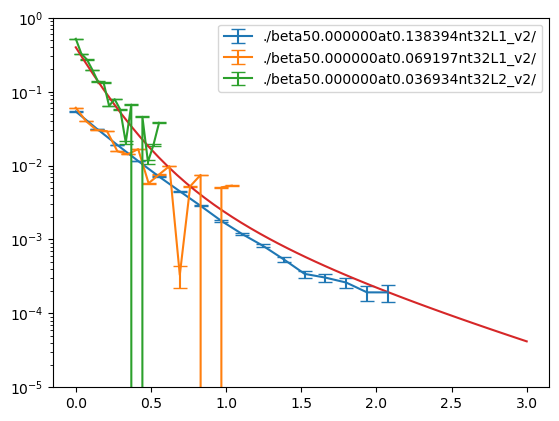

In [26]:
plt.yscale("log")

for res in res_list:
    Nt = res[1].shape[0]

    at = float(res[0].split("at")[1].split("nt")[0])
    xx=np.arange(int(Nt/2)) * at
    # xx=np.arange(Nt)
    yy=res[1][:int(Nt/2)]
    dy=res[2][:int(Nt/2)]

    plt.errorbar( xx, yy, dy, capsize=5, label=res[0] )

# xx=np.arange(Nt)
# yy= 0.07*np.exp( -np.sqrt(2.0) * xx / 8.0 )
# plt.plot( xx, yy )

xx=np.linspace(0,3.0,50)
# yy= 0.02*np.exp( -np.sqrt(2.0) * xx * 2.4 )
yy= 0.0006*f(xx, 10)
plt.plot( xx, yy )



plt.legend()
plt.ylim( 1.0e-5, 1.0e0 )

In [9]:
50.0/8.0

6.25